# **Calculating GHG Fluxes from Raw Emission Data**
### Clark Jackson, Dr. Jacob Hosen; Purdue University

### Background
Carbon, like any natural matter, is in a constant state of change. What about it is changing? Its form, derivation, makeup, and energetic potential to name a few. Check out this [helpful video](https://oceanservice.noaa.gov/facts/carbon-cycle.html#transcript) and web page by the National Oceanographic and Atmospheric Administration (NOAA) that further explains the carbon cycle. Scientists seek to understand these state changes by quantifying the various measurable forms that carbon can take at any given point in time. Oftentimes, this can mean measuring gases and atmospheric exchange of terrestrial and aquatic environments. In order to do this, however, we need to quantify the amount of gas that is transferring between states (i.e., diffusion from surface water to atmosphere). This exemplifies the importance understanding flux dynamics in natural landscapes.

<div>
<img src="images/Carbon-Cycle-Diagram.png" width="700"/>
</div>

### $CH_4$ Fluxes in Wetlands
Although carbon dioxide has long been a flagship species for climate scientists stressing the effects of climate change, methane is equally as potent. It combats its shorter lifespan with a global warming potential (GWP) of nearly 30x that of $CO_2$. The data we will be using in this exercise is raw methane data pulled from mid-latitude temperate wetlands. This data was collected as part of a larger study that sought to examine and quantify the effects of seasonality, rapid thawing events, and other environmental drivers on wetland methane emissions. This goal is rooted in the need to produce more accurate flux estimates for natural ecosystems, and specifically wetlands since they account for the majority of said fluxes. The [Global Carbon Project](https://www.globalcarbonproject.org/methanebudget/) releases regular updates on carbon fluxes in several forms, but of interest to us was the global methane budget. Methane flux estimates from wetlands had the highest amount of variability relative to any other category, emphasizing the need to better quantify fluxes from these habitats.

<div>
<img src="images/MethaneInfographic2024.png" width="700"/>
</div>

### Data Specifics and Context
Emission data can be measured and collected in a multitude of ways, so it is important to briefly discuss the specifics of the data you will be using for this learning module to give you context. First, this methane data was collected using *in-situ* autonomous dataloggers which continuously recorded data at 30-second intervals and deployments lasted about 40-45 hours. The chambers were equipped with mini air pumps which evacuated the internal headspace at a regular interval to prevent oversaturation of methane and thus faulty data. Additionally, a 2-meter long tube connected to the side of the bucket and wrapped around it reduced the possibility of a pressure differential. If the pressure inside the chamber was higher than the pressure outside the chamber, gas at the substrate surface would be less likely to diffuse out as a result. However, gas did not leak out of the tube unless the buildup was far too great for the air pump to keep under control, which was not observed. 

The important thing for you to understand before starting this exercise is what this method of data capture makes the data itself look like. You will notice after plotting emission data below, that there are buildups of methane concentration followed by sharp declines back to an ambient level. This is the pump in action, preventing what would otherwise be an asymptotic relationship by which the methane would reach peak concentration in our chamber and stop increasing altogether. 

Alright, thats enough introductory information - let's begin the exercise!

## Step 1
We are going to be working out of the dplyr package in R, read about it [here](https://dplyr.tidyverse.org/) to explore what features this package offers. We are going to start by pulling data from a pre-loaded data set with CH4 concentration data. 

In [45]:
library(dplyr)
ch4_raw_dat <- readRDS("Files/flux_ppm_dat.rds")

## Step 2
Now we are going to add some columns to our data frame. In order to appropriately calculate flux values, we need to have an associated time window for duration these cycles take place. Because this data is being pulled from an existing data set with an existing experimental design and collection apparatus, we are going to base the manipulations in this step after that. For instance, you will notice that the new column `cycle_length` is valued at 3.5 hours and the `pump_on_start` column is only 3 hours. This matches how this data was collected - the built-in air pump flipped on every 3 hours for approximately 30 minutes to evacuate the chamber of pre-existing gases. Therefore, we want to create a column called `pump` which essentially tells our future code whether or not the pump is on. Only data in between these pump cycles will be kept

In [47]:
ch4_raw_dat <- ch4_raw_dat %>%
  mutate(
    elapsed_seconds = time_epoch - first(time_epoch),
    cycle_length = 210 * 60, # total cycle length is 3.5 hours
    pump_on_start = 180 * 60, # the final 30 minutes of each cycle is pump-down time
    position_in_cycle = elapsed_seconds %% cycle_length,
    pump = as.factor(ifelse(position_in_cycle >= pump_on_start, 1, 0)) # this conditional designates pump-down time as 1 and off time as 0
    )

### -- Data Check --
Let's make sure the changes we've made are actually doing what we want them to. Plot the data below, and you should see two differently colored portions of the data set. When the pump is 0 (off), the gas concentration rises over time. When the pump kicks on (1), the color changes and you can see the pump-down in effect.

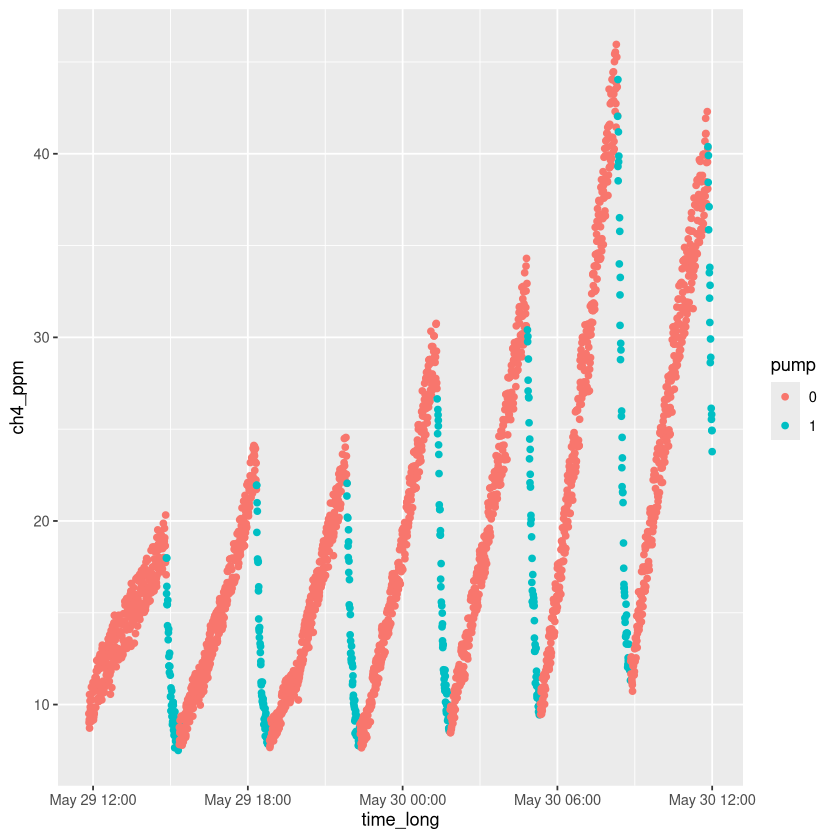

In [48]:
ggplot(ch4_raw_dat, aes(time_long, ch4_ppm, color = pump))+geom_point()

## Step 3
Looks great! Okay let's continue; next we want to modify our data frame so that we can isolate each individual flux cycle to generate values specific to it. We'll start by using the code block below, which essentially creates a new data set from our current data and uses a couple functions that assign unique cycle ID's to each one. Since our pump column naturally separates our data, `pump != lag(pump...)` browses through the data and compares the pump column value in one row to the row behind it. If it notices a change (i.e., pump turning on --> 0 to 1) then it returns FALSE. Then, `cumsum()` cumulatively sums those TRUE/FALSE values so that the new `pump_cycle` column is labeled as 0, 1, 2, 3, etc. for each new flux cycle.

In [49]:
# create a new data frame from our methane data that assigns pump cycles
working_data <- ch4_raw_dat %>%
  mutate(pump_cycle = cumsum(pump != lag(pump, default = first(pump))))

## Step 4
Now that we solidified that pump cycle identification column, we want to attribute some new variables that we will need to create flux variables. The code block below sorts the data into each pump cycles then assigns a start and end time for each one. 

In [50]:
# pulling all data outside of the pump-down cycle (if pump = 1, that means it's on and is evacuating the chamber)
interval_df <- working_data %>%
  filter(pump == 0) %>%
  group_by(pump_cycle) %>% # grouping each flux cycle
  summarise(
    cycle = cur_group_id(), # attaching a cycle ID
    start = min(time_long), # the flux start time
    end = max(time_long), # the flux end time
    .groups = 'drop'
  )

## Step 5
Bear with me! I know the code chunk below looks crazy, but it's actually pretty straight forward. This creates a new data frame that will hold our flux and other notable variables of interest. Then, it isolates each cycle and generates a flux value using the equation listed in the code below with all the necessary inputs listed right before it. Then, we select the columns we want to keep and can inspect our new flux data set! All flux values have been calculated in mg/L $CH_4$ m<sup>-2</sup> hr<sup>-1</sup>.  

In [2]:
# Now that preparation is done, we can actually calculate some fluxes
ch4_flux_data <- interval_df %>%
  rowwise() %>%
  mutate(
    interval_data = list(working_data %>% # creates a list in each row which has all ppm data corresponding to that flux cycle
        filter(time_long >= start & time_long <= end))
  ) %>%
  filter(nrow(interval_data) >= 20) %>% # if any rows have less than 20 data points, we assume that there is no flux value
  mutate(
    mean_temp_C = mean(interval_data$temp_C), # finding the average temperature during this flux cycle
    mean_hum = mean(interval_data$humidity), # finding the average humidity during this flux cycle
    y_start = mean(head(interval_data$ch4_ppm, 7)), # this assigns the starting concentration value
    y_end = mean(tail(interval_data$ch4_ppm, 7)), # this assigns the ending concentration value
    y_diff = y_end - y_start, # this finds the difference in cocncentration
    time_diff_hours = as.numeric(difftime(end, start, units = "hours")), # should be approximately 3 hours (build-up time)
    chamber_footprint = 0.07068, # in m^2, the surface area our chamber opening covers
    chamber_volume = 18, # in L, the volume of our chamber
    conc_conv = 0.000656, # this is a gas constant used to convert ppm values to mg at standard conditions, specifically for CH4
    flux_value = ((y_diff / time_diff_hours) * conc_conv * (chamber_volume / chamber_footprint)), # the actual flux equation
    site = first(interval_data$site)
  ) %>%
  ungroup() %>% 
  dplyr::select(cycle, start, end, y_start, y_end, y_diff, time_diff_hours, flux_value, # selecting which rows to keep 
                mean_temp_C, mean_hum, site) 

ERROR: Error in interval_df %>% rowwise() %>% mutate(interval_data = list(working_data %>% : could not find function "%>%"


### That's it!
Check your new flux data frame to make sure your flux values have been produced. 

In [1]:
head(ch4_flux_dat, 7)

ERROR: Error: object 'ch4_flux_dat' not found
